# Executive Summary

This project analyzes customer churn patterns using customer demographic, service, and billing data. The analysis identifies key factors influencing customer attrition, including contract type, internet service, payment method, tenure, and monthly charges. The findings provide actionable recommendations to improve customer retention and reduce churn.

In [182]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries installed successfully!")

All libraries installed successfully!


In [183]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in this folder:")
print(os.listdir())

Current folder:
c:\Users\Sravani\Desktop\Customer-Churn-Analysis\notebooks

Files in this folder:
['churn_analysis.ipynb', 'Telco_customer_churn.xlsx']


In [184]:
import pandas as pd

df = pd.read_excel("Telco_customer_churn.xlsx")

print(df.head())

   CustomerID  Count        Country       State         City  Zip Code  \
0  3668-QPYBK      1  United States  California  Los Angeles     90003   
1  9237-HQITU      1  United States  California  Los Angeles     90005   
2  9305-CDSKC      1  United States  California  Los Angeles     90006   
3  7892-POOKP      1  United States  California  Los Angeles     90010   
4  0280-XJGEX      1  United States  California  Los Angeles     90015   

                 Lat Long   Latitude   Longitude  Gender  ...        Contract  \
0  33.964131, -118.272783  33.964131 -118.272783    Male  ...  Month-to-month   
1   34.059281, -118.30742  34.059281 -118.307420  Female  ...  Month-to-month   
2  34.048013, -118.293953  34.048013 -118.293953  Female  ...  Month-to-month   
3  34.062125, -118.315709  34.062125 -118.315709  Female  ...  Month-to-month   
4  34.039224, -118.266293  34.039224 -118.266293    Male  ...  Month-to-month   

  Paperless Billing             Payment Method  Monthly Charges Tota

In [185]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 33)


In [186]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [187]:
print(df["Churn Label"].value_counts())

Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


# Data Cleaning

The dataset was inspected for missing values, data types, and inconsistencies. Necessary preprocessing steps were performed to ensure data quality before conducting the analysis.

In [188]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


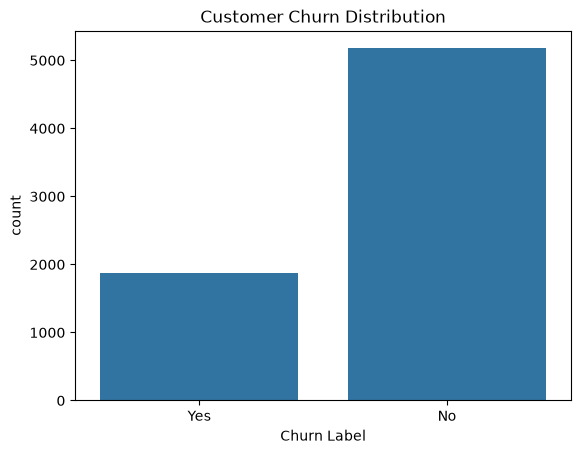

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Churn Label", data=df)
plt.title("Customer Churn Distribution")
plt.show()

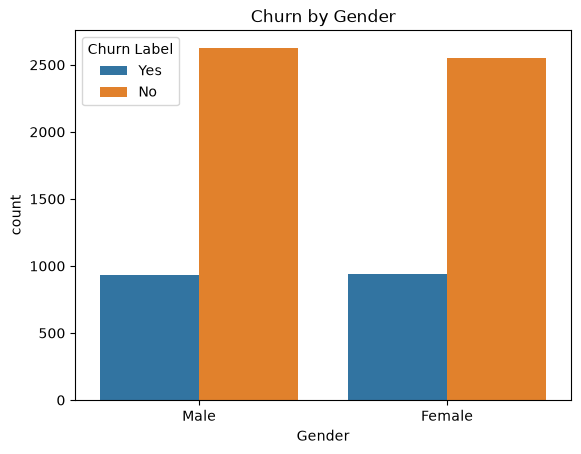

In [190]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Gender", hue="Churn Label", data=df)
plt.title("Churn by Gender")
plt.show()

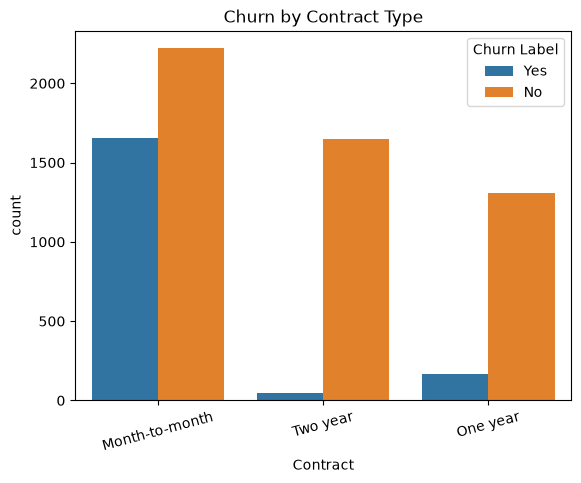

In [191]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Churn by Contract Type")
plt.xticks(rotation=15)
plt.show()

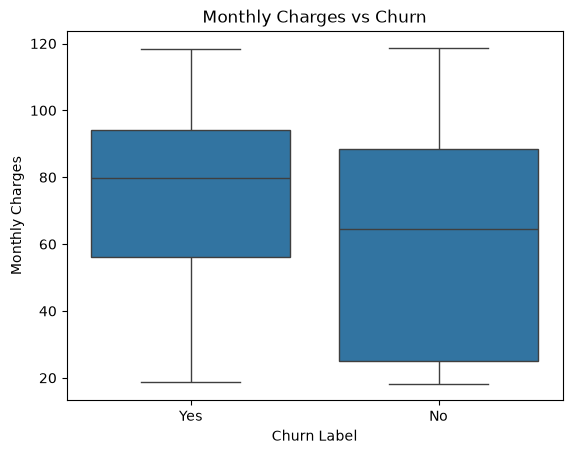

In [192]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

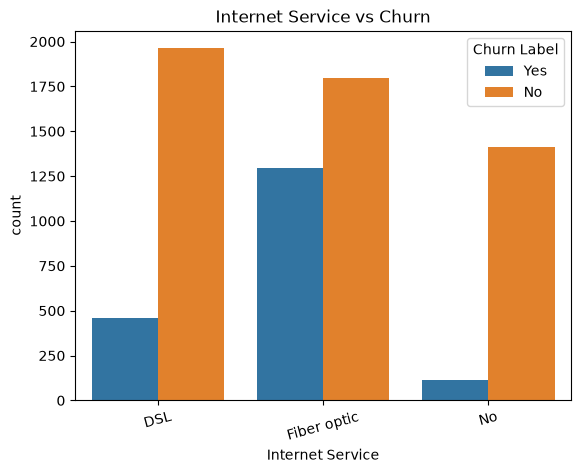

In [193]:
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Internet Service vs Churn")
plt.xticks(rotation=15)
plt.show()

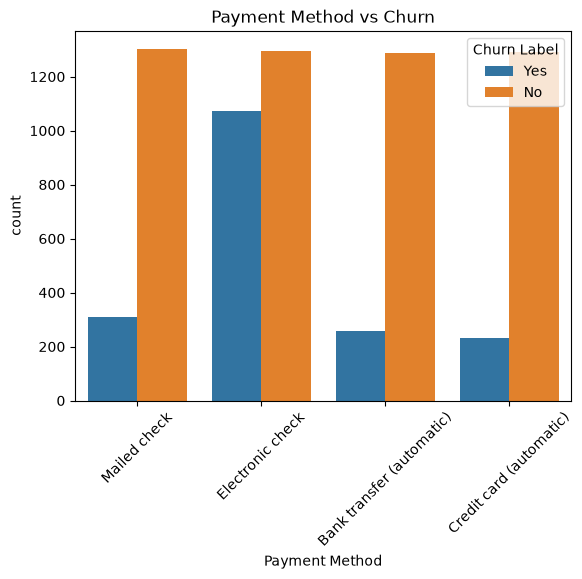

In [194]:
sns.countplot(x="Payment Method", hue="Churn Label", data=df)
plt.title("Payment Method vs Churn")
plt.xticks(rotation=45)
plt.show()

In [195]:
churn_rate = (df["Churn Label"] == "Yes").mean() * 100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

Overall Churn Rate: 26.54%


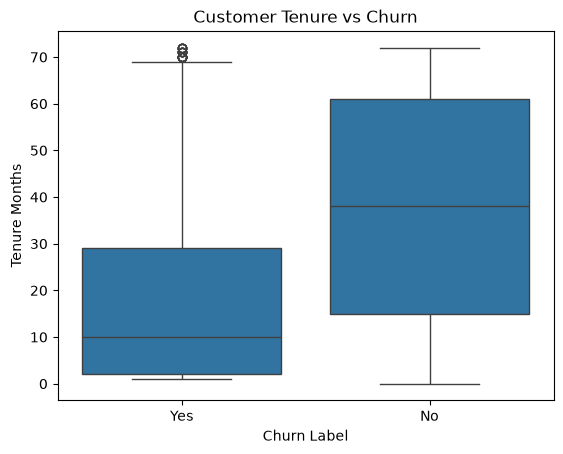

In [196]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="Churn Label", y="Tenure Months", data=df)
plt.title("Customer Tenure vs Churn")
plt.show()

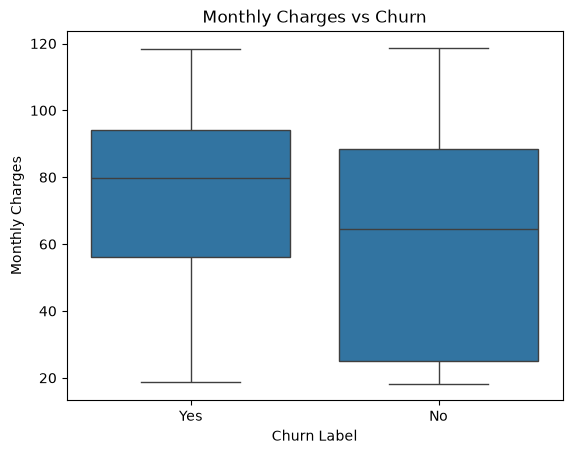

In [197]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

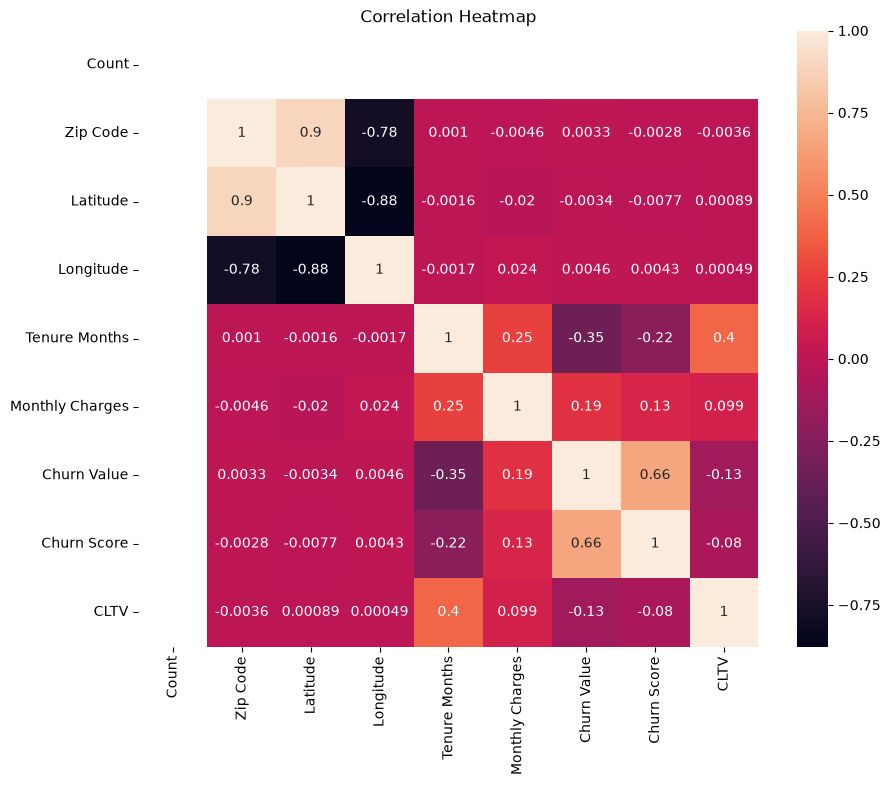

In [198]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [199]:
df["Churn Reason"].value_counts().head(10)

Churn Reason
Attitude of support person                   192
Competitor offered higher download speeds    189
Competitor offered more data                 162
Don't know                                   154
Competitor made better offer                 140
Attitude of service provider                 135
Competitor had better devices                130
Network reliability                          103
Product dissatisfaction                      102
Price too high                                98
Name: count, dtype: int64

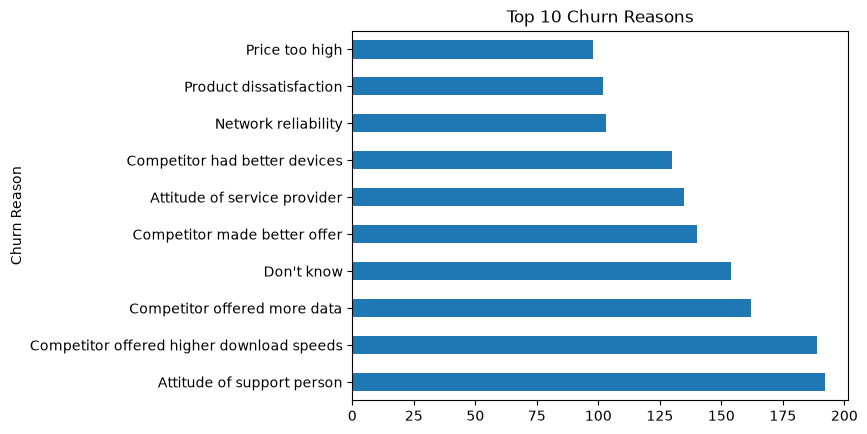

In [200]:
df["Churn Reason"].value_counts().head(10).plot(kind="barh")
plt.title("Top 10 Churn Reasons")
plt.show()

Customer Churn Analysis
Project Objective

The objective of this project is to analyze customer churn patterns and identify the key factors that influence customer attrition. By understanding customer behavior, the company can develop strategies to improve customer retention and reduce churn.

Importing Required Libraries
Description

The following Python libraries are used for data analysis and visualization:

Pandas for data manipulation
NumPy for numerical operations
Matplotlib for plotting graphs
Seaborn for data visualization
Loading the Dataset
Description

The customer churn dataset is loaded from an Excel file into a Pandas DataFrame for analysis.

Exploratory Data Analysis (EDA)
Description

Exploratory Data Analysis is performed to understand the structure of the dataset, identify important variables, and discover patterns related to customer churn.

Customer Churn Distribution
Description

This analysis shows the overall distribution of churned and retained customers.

Observation

The majority of customers remain with the company, while a significant portion of customers have churned.

Churn Analysis by Gender
Description

This visualization compares churn behavior across male and female customers.

Observation

Customer churn is relatively similar across genders, indicating that gender is not a major factor influencing churn.

Churn Analysis by Contract Type
Description

This analysis examines the relationship between customer contract type and churn.

Observation

Customers with Month-to-month contracts exhibit the highest churn rate compared to customers with one-year and two-year contracts.

Business Insight

Encouraging customers to switch to long-term contracts may improve customer retention.

Churn Analysis by Internet Service
Description

This analysis evaluates churn patterns across different internet service types.

Observation

Fiber optic customers show the highest churn rate among all internet service categories.

Business Insight

The company should investigate pricing, service quality, and customer satisfaction among fiber optic users.

Churn Analysis by Payment Method
Description

This analysis examines the relationship between payment methods and customer churn.

Observation

Customers using Electronic Check have the highest churn rate.

Business Insight

The company should identify potential issues associated with electronic payment experiences.

Customer Tenure Analysis
Description

This analysis explores how customer tenure affects churn behavior.

Observation

Customers with shorter tenure are more likely to churn than long-term customers.

Business Insight

Early customer engagement and retention programs can reduce churn.

Monthly Charges Analysis
Description

This analysis investigates the impact of monthly charges on customer churn.

Observation

Customers with higher monthly charges tend to churn more frequently.

Business Insight

Reviewing pricing strategies and offering personalized plans may improve retention.

Churn Reasons Analysis
Description

This section identifies the most common reasons customers leave the company.

Observation

Competitor offers, pricing concerns, and service-related issues are among the primary causes of customer churn.

Conclusion
Key Findings
The overall churn rate is significant and requires attention.
Month-to-month contract customers have the highest churn rate.
Fiber optic customers are more likely to churn.
Electronic Check users show higher churn behavior.
New customers are more likely to leave than long-term customers.
Higher monthly charges are associated with increased churn.
